In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import category_encoders as ce
plt.style.use('ggplot')
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", category=Warning)
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix

In [3]:
df = pd.read_csv('Bank_Personal_Loan_Modelling.csv.')
df

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


Attribute Information:

ID : Customer ID

Age : Customer's age in completed years

Experience : #years of professional experience

Income : Annual income of the customer ($000)

ZIP Code : Home Address ZIP code.

Family : Family size of the customer

CCAvg : Avg. spending on credit cards per month ($000)

Education : Education Level.
1: Undergrad;
2: Graduate;
3: Advanced/Professional

Mortgage : Value of house mortgage if any. ($000)

10.Personal Loan : Did this customer accept the personal loan offered in the last campaign?

11.Securities Account : Does the customer have a securities account with the bank?

12.CD Account : Does the customer have a certificate of deposit (CD) account with the bank?

13.Online : Does the customer use internet banking facilities?

14.Credit card : Does the customer use a credit card issued by

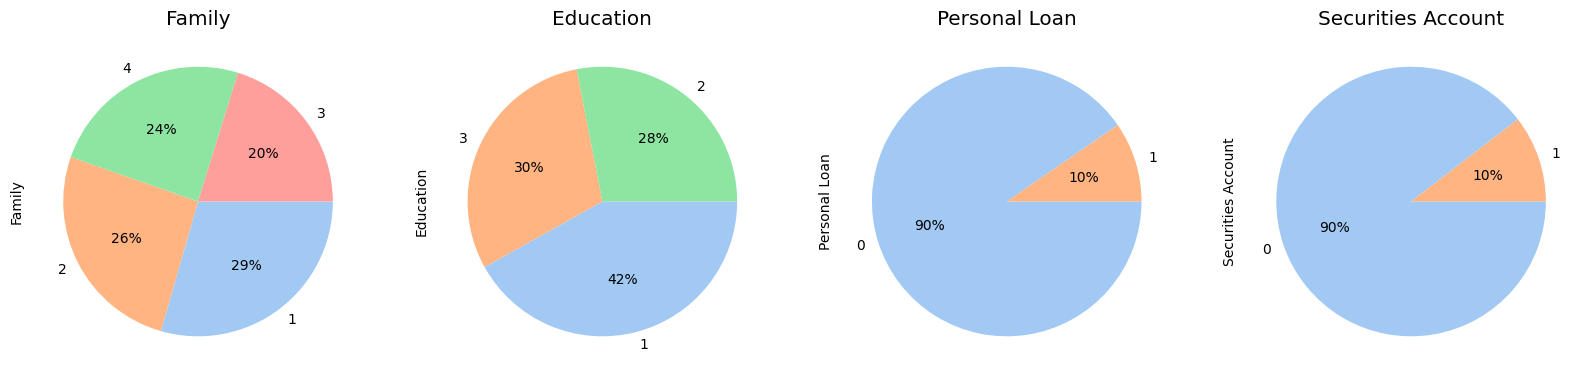

In [5]:
# class distribution

plt.figure(figsize=(20,20))
colors = sns.color_palette('pastel')

plt.subplot(1, 4, 1)
df['Family'].value_counts().plot.pie(counterclock=False, autopct='%.0f%%', colors = colors)
plt.title('Family')

plt.subplot(1, 4, 2)
df['Education'].value_counts().plot.pie(counterclock=False, autopct='%.0f%%', colors = colors)
plt.title('Education')

plt.subplot(1, 4, 3)
df['Personal Loan'].value_counts().plot.pie(counterclock=False, autopct='%.0f%%', colors = colors)
plt.title('Personal Loan')

plt.subplot(1, 4, 4)
df['Securities Account'].value_counts().plot.pie(counterclock=False, autopct='%.0f%%', colors = colors)
plt.title('Securities Account')

plt.show()

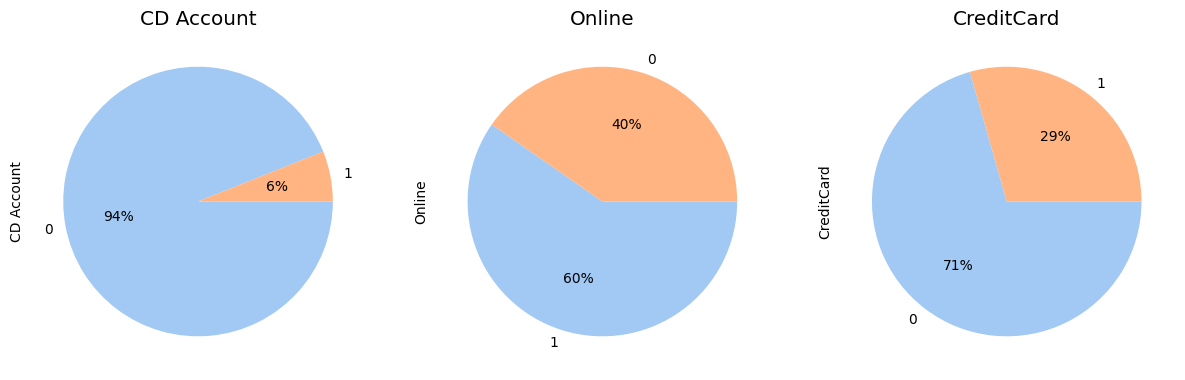

In [6]:
# class distribution

plt.figure(figsize=(20,20))
colors = sns.color_palette('pastel')

plt.subplot(1, 4, 1)
df['CD Account'].value_counts().plot.pie(counterclock=False, autopct='%.0f%%', colors = colors)
plt.title('CD Account')

plt.subplot(1, 4, 2)
df['Online'].value_counts().plot.pie(counterclock=False, autopct='%.0f%%', colors = colors)
plt.title('Online')

plt.subplot(1, 4, 3)
df['CreditCard'].value_counts().plot.pie(counterclock=False, autopct='%.0f%%', colors = colors)
plt.title('CreditCard')

plt.show()

In [7]:
# Drop kolom yang tidak diperlukan
data = df.drop(columns=['ID'])  # Misalnya, kolom 'id' tidak diperlukan

In [8]:
corrmat = df.corr() 
corrmat # berisi matriks korelasi antar variabel dalam df

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,1.000000,-0.008473,-0.008326,-0.017695,0.013432,-0.016797,-0.024675,0.021463,-0.013920,-0.024801,-0.016972,-0.006909,-0.002528,0.017028
Age,-0.008473,1.000000,0.994215,-0.055269,-0.029216,-0.046418,-0.052012,0.041334,-0.012539,-0.007726,-0.000436,0.008043,0.013702,0.007681
Experience,-0.008326,0.994215,1.000000,-0.046574,-0.028626,-0.052563,-0.050077,0.013152,-0.010582,-0.007413,-0.001232,0.010353,0.013898,0.008967
Income,-0.017695,-0.055269,-0.046574,1.000000,-0.016410,-0.157501,0.645984,-0.187524,0.206806,0.502462,-0.002616,0.169738,0.014206,-0.002385
ZIP Code,0.013432,-0.029216,-0.028626,-0.016410,1.000000,0.011778,-0.004061,-0.017377,0.007383,0.000107,0.004704,0.019972,0.016990,0.007691
Family,-0.016797,-0.046418,-0.052563,-0.157501,0.011778,1.000000,-0.109275,0.064929,-0.020445,0.061367,0.019994,0.014110,0.010354,0.011588
CCAvg,-0.024675,-0.052012,-0.050077,0.645984,-0.004061,-0.109275,1.000000,-0.136124,0.109905,0.366889,0.015086,0.136534,-0.003611,-0.006689
Education,0.021463,0.041334,0.013152,-0.187524,-0.017377,0.064929,-0.136124,1.000000,-0.033327,0.136722,-0.010812,0.013934,-0.015004,-0.011014
Mortgage,-0.013920,-0.012539,-0.010582,0.206806,0.007383,-0.020445,0.109905,-0.033327,1.000000,0.142095,-0.005411,0.089311,-0.005995,-0.007231
Personal Loan,-0.024801,-0.007726,-0.007413,0.502462,0.000107,0.061367,0.366889,0.136722,0.142095,1.000000,0.021954,0.316355,0.006278,0.002802


Nilai korelasi berkisar dari -1 hingga 1, di mana:
1 menunjukkan korelasi positif sempurna (korelasi positif maksimum).
-1 menunjukkan korelasi negatif sempurna (korelasi negatif maksimum).
0 menunjukkan tidak adanya korelasi.i.

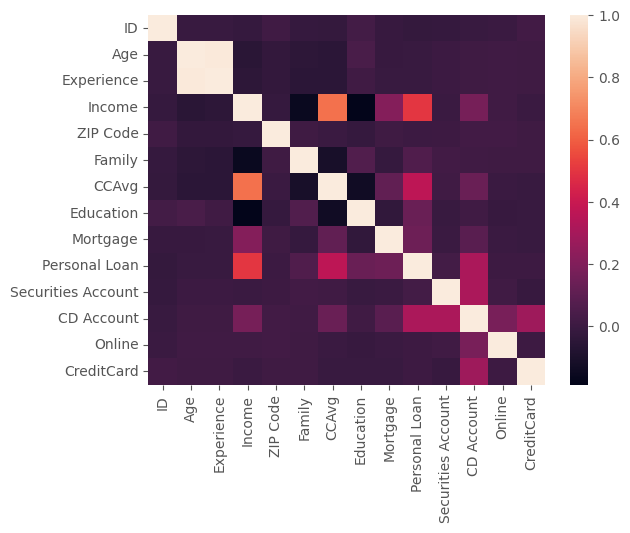

In [13]:
import seaborn as sns
ax=sns.heatmap(df.corr(method ='pearson'))

# Mendeteksi Data yang hilang

In [14]:
df.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

# Mendeteksi adanya Outliers

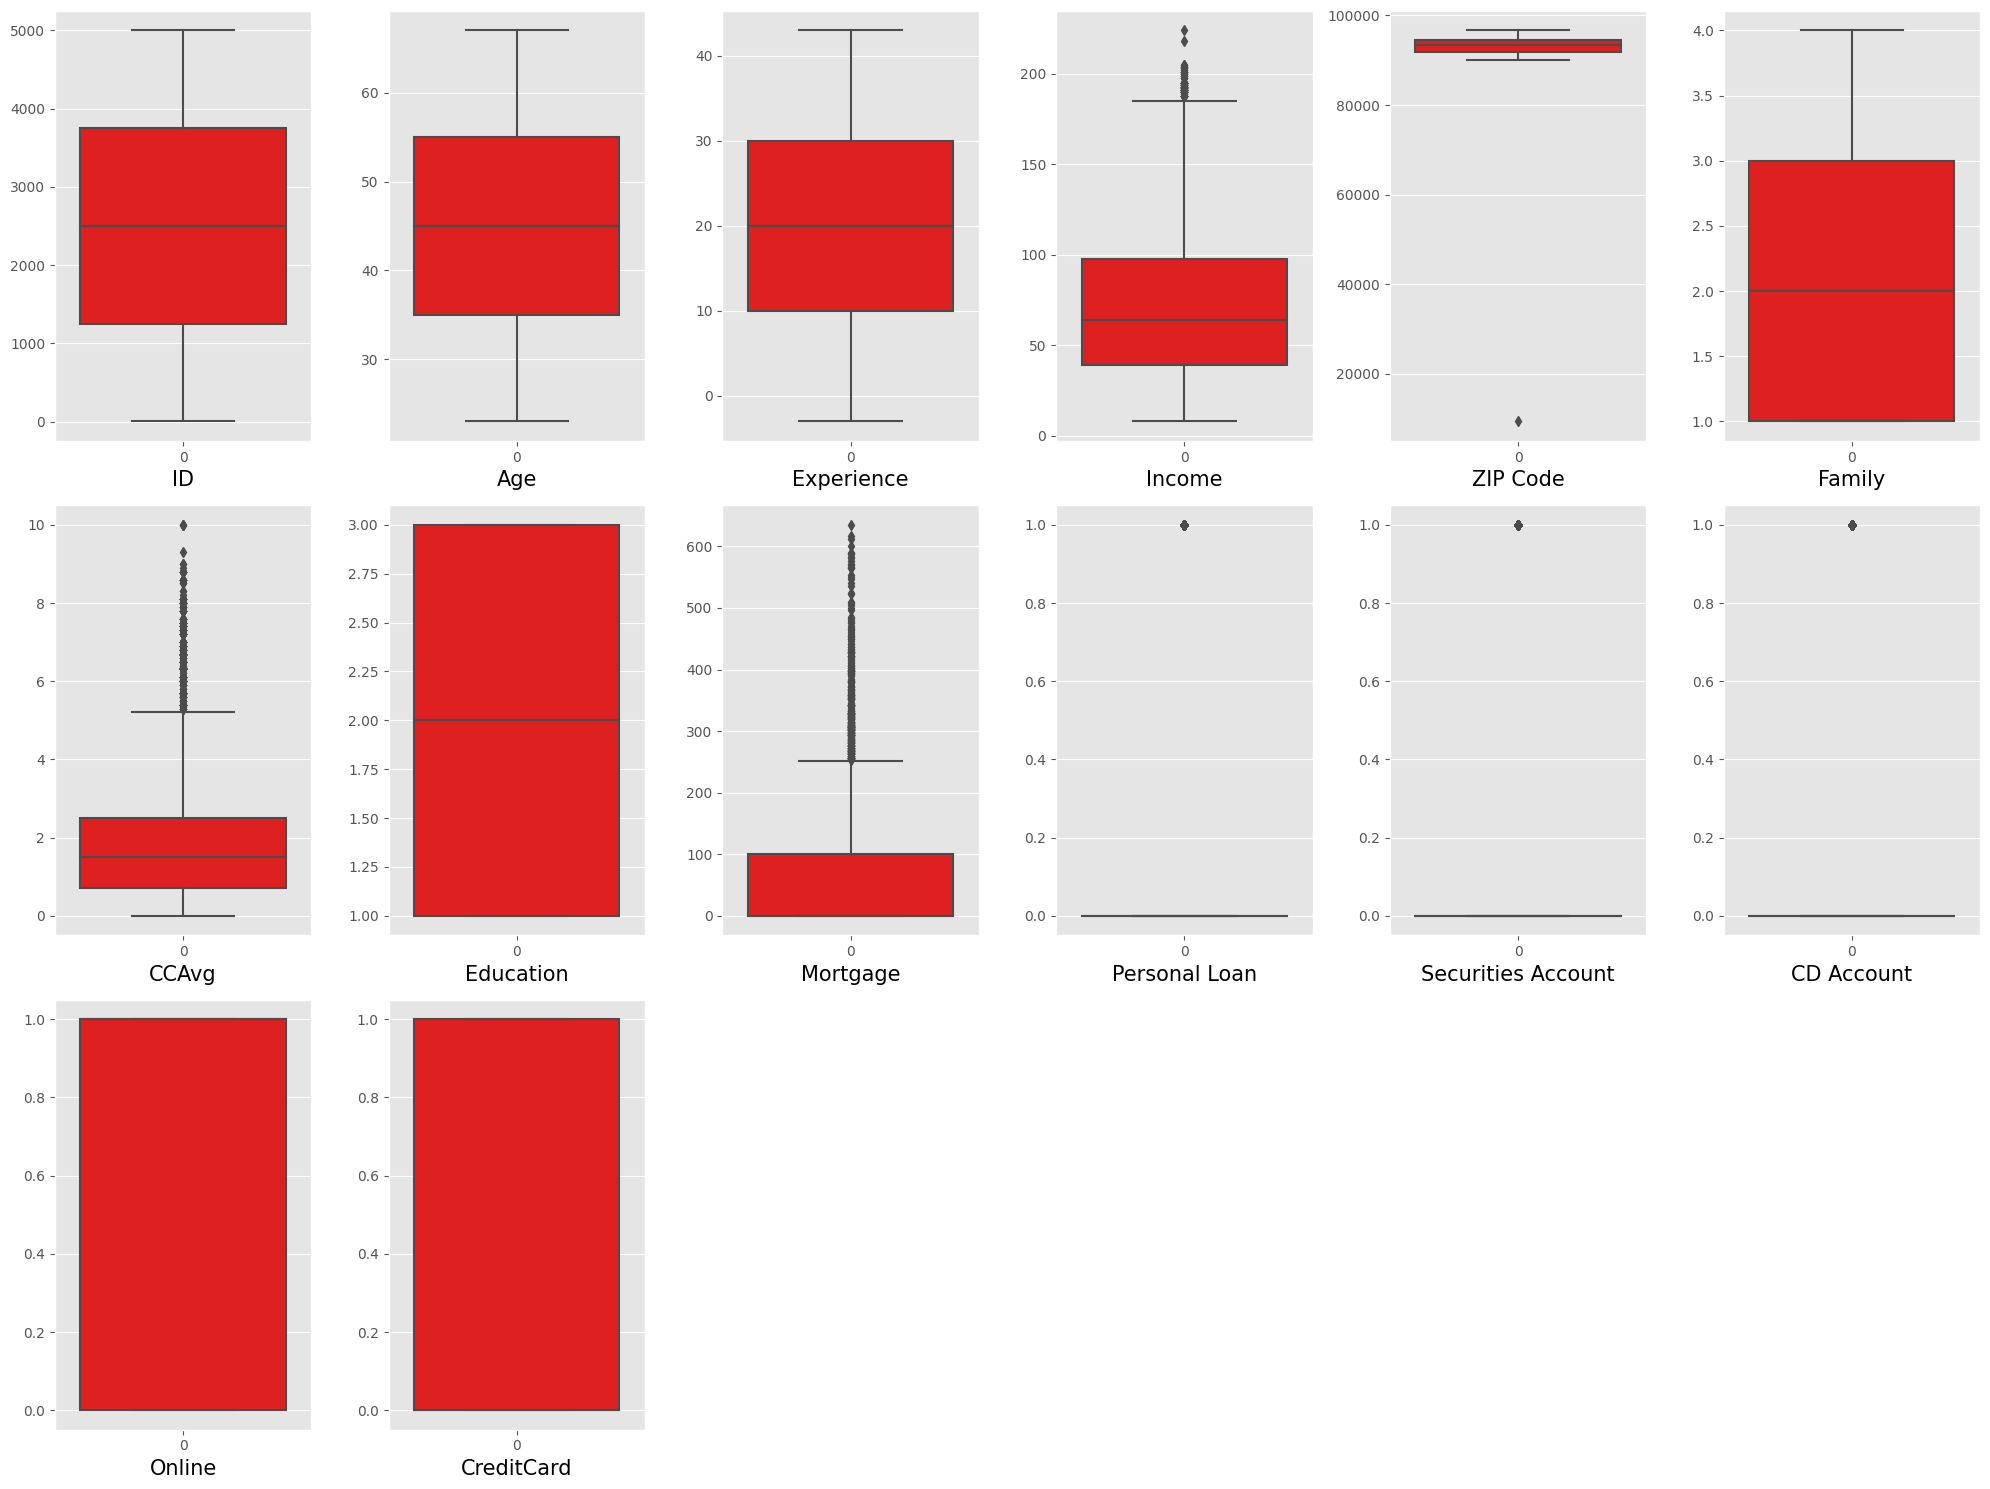

In [18]:
plt.figure(figsize=(20, 15))
plotnumber = 1

for col in df.columns:
    if plotnumber <= 18:  # Menyesuaikan batas plot hingga 18
        ax = plt.subplot(3, 6, plotnumber)  # Mengubah ke grid 3x6 untuk 18 boxplot
        sns.boxplot(df[col], color='r')
        plt.xlabel(col, fontsize=15)

    plotnumber += 1

plt.tight_layout()
plt.show()

# Menghapus Outliers

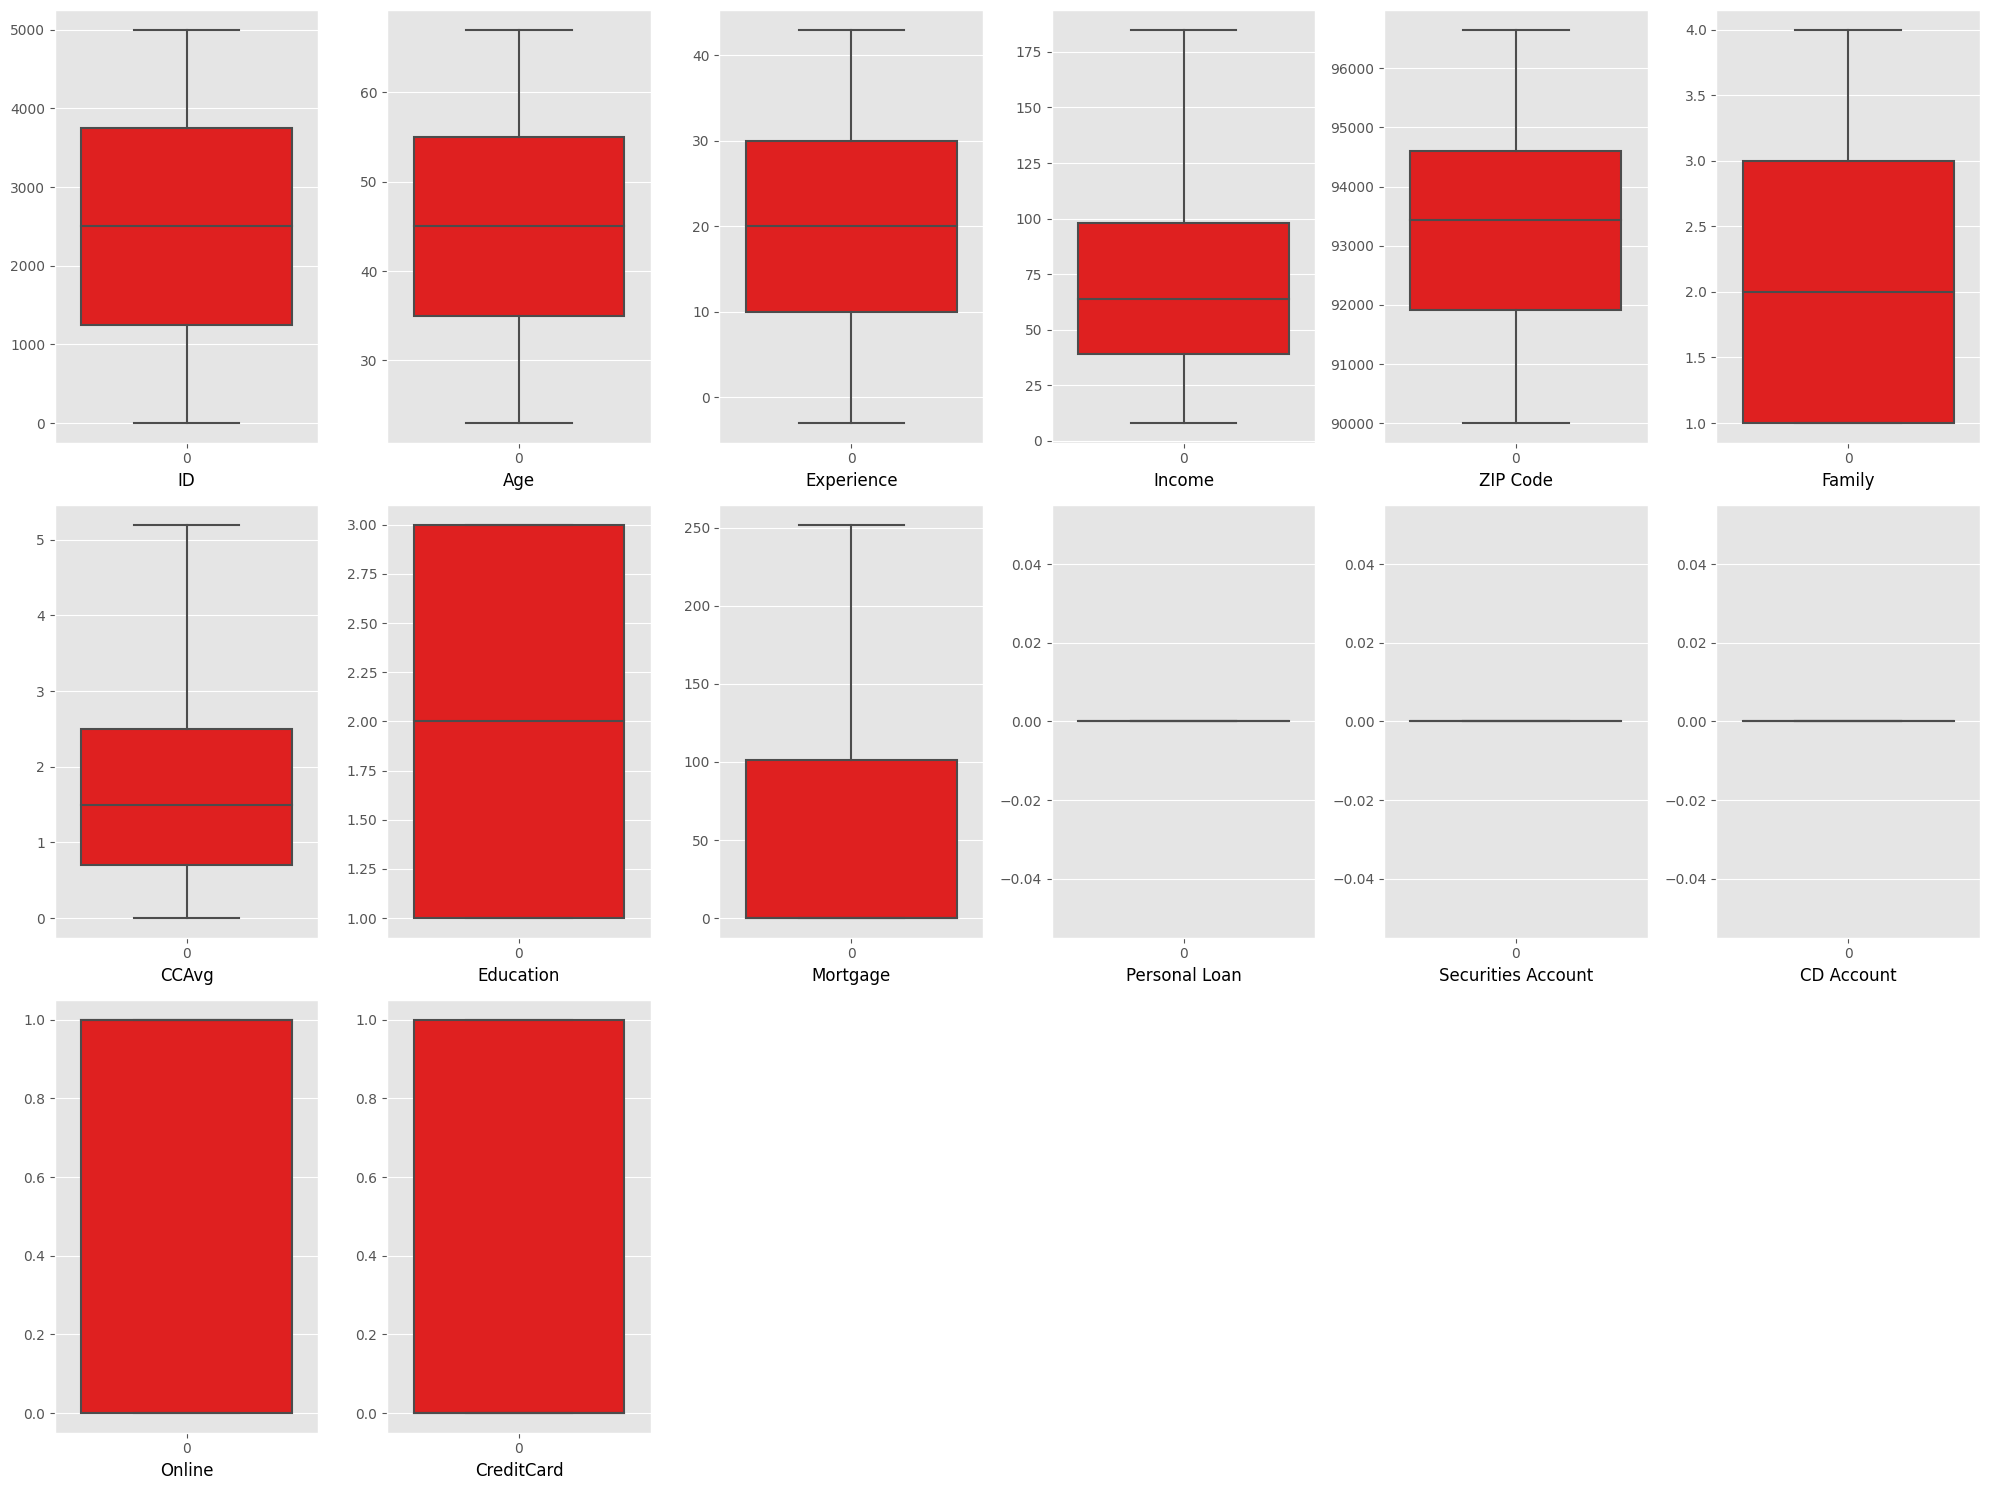

In [20]:
plt.figure(figsize=(20, 15))
plotnumber = 1

for col in df.columns:
    if plotnumber <= 18:
        ax = plt.subplot(3, 6, plotnumber)  # Mengubah jumlah subplot menjadi 3 baris dan 6 kolom
        sns.boxplot(df[col], color='r', sym='')  # Menyembunyikan outliers
        plt.xlabel(col, fontsize=12)
    
    plotnumber += 1

plt.tight_layout()
plt.show()

# Split into train and test

In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score 
from sklearn.model_selection import train_test_split # Membagi dataset menjadi data train dan test
X,y = df.drop(columns='Personal Loan'), df['Personal Loan']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

# Menampilkan persentase pembagian data
percentage_train = len(X_train) / len(df) * 100
percentage_test = len(X_test) / len(df) * 100

print("Persentase Data Train:", percentage_train, "%")
print("Persentase Data Test:", percentage_test, "%")

Train shape: (4000, 13) (4000,)
Test shape: (1000, 13) (1000,)
Persentase Data Train: 80.0 %
Persentase Data Test: 20.0 %


# SVM LINEAR

In [46]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [47]:
# SVM Linear
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

SVC(kernel='linear')

In [48]:
# Melakukan prediksi pada data test / pengujian
y_pred = svm_linear.predict(X_test)

In [49]:
# Menampilkan classification report
accuracy = accuracy_score(y_test, y_pred) # menghitung akurasi model klasifikasi
report = classification_report(y_test, y_pred) # merincikan laporan klasifikasi 
print(f'Akurasi: {accuracy}')
print("Classification Report:\n", report)

Akurasi: 0.923
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96       910
           1       0.62      0.37      0.46        90

    accuracy                           0.92      1000
   macro avg       0.78      0.67      0.71      1000
weighted avg       0.91      0.92      0.91      1000



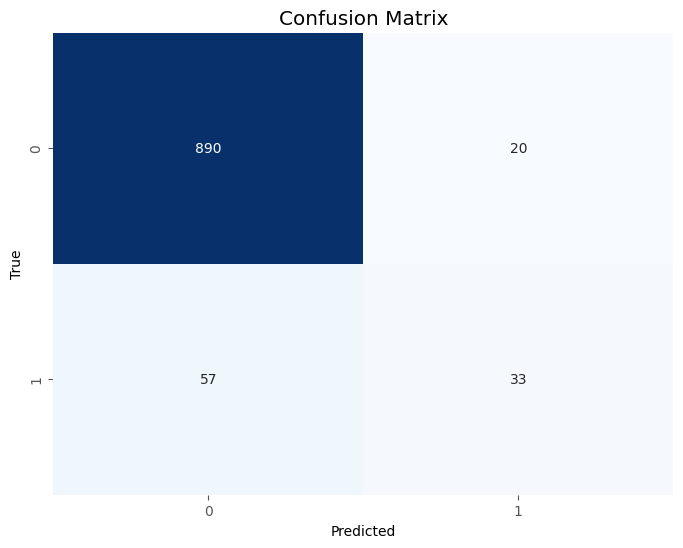

In [50]:
cm = confusion_matrix(y_test, y_pred) # Menghitung confusion matrix berdasarkan label 

# Visualisasi confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()